In [1]:
# Kütüphanelerin içe aktarılması
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
# Rastgeleliğin sabitlenmesi (Tekrarlanabilirlik)
np.random.seed(42)

In [3]:
# Görsel stil ve tema ayarları
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

In [4]:
# Pandas görüntüleme ayarları (tüm sütunlar ve 2 basamak ondalık)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

In [5]:

print("Ortam ve kütüphane ayarları tamamlandı.")

Ortam ve kütüphane ayarları tamamlandı.


In [6]:

n = 1000

# 1. Sentetik temel sütunlar
yas = np.random.randint(18, 70, size=n).astype(float)
gelir = np.random.normal(35000, 10000, size=n).round(2)

In [7]:


# Kasıtlı yazım farklılıkları barındıran şehir listesi
sehirler = np.random.choice(
    ["İstanbul", "istanbul", "Ankara", "ANKARA ", " İzmir", "Bursa", "bursa"],
    size=n,
    p=[0.35, 0.15, 0.20, 0.10, 0.10, 0.05, 0.05]
)

abonelik_tipi = np.random.choice(["Standart", "Premium", "VIP"], size=n, p=[0.50, 0.35, 0.15])
kayit_tarihi = pd.date_range(start="2023-01-01", periods=n, freq="D")
aylik_harcama = np.random.exponential(scale=1500, size=n).round(2)
memnuniyet_puani = np.random.choice([1.0, 2.0, 3.0, 4.0, 5.0, np.nan], size=n, p=[0.1, 0.15, 0.25, 0.3, 0.15, 0.05])
churn = np.random.choice([0, 1], size=n, p=[0.80, 0.20])


In [8]:
# DataFrame oluşturma
df = pd.DataFrame({
    "yas": yas,
    "gelir": gelir,
    "sehir": sehirler,
    "abonelik_tipi": abonelik_tipi,
    "kayit_tarihi": kayit_tarihi,
    "aylik_harcama": aylik_harcama,
    "memnuniyet_puani": memnuniyet_puani,
    "churn": churn
})

In [9]:

# Eksik değerler (NaN)
df.loc[np.random.choice(n, 45, replace=False), "gelir"] = np.nan
df.loc[np.random.choice(n, 30, replace=False), "yas"] = np.nan


In [10]:
# Gelir sütununa aşırı uç değerler (Outliers)
outlier_idx = np.random.choice(n, 12, replace=False)
df.loc[outlier_idx, "gelir"] = df.loc[outlier_idx, "gelir"] * 18

In [11]:
# Mantıksız yaş değerleri (-5 ve 150)
df.loc[np.random.choice(n, 6, replace=False), "yas"] = -5
df.loc[np.random.choice(n, 6, replace=False), "yas"] = 150

In [12]:
# Yinelenen (Duplicate) satırlar ekleme
tekrar_edenler = df.sample(15, random_state=42)
df = pd.concat([df, tekrar_edenler], ignore_index=True)

In [13]:
print("Sentetik ve kirletilmiş veri seti başarıyla oluşturuldu.")

Sentetik ve kirletilmiş veri seti başarıyla oluşturuldu.


In [14]:

# Boyut kontrolü
print(f"Toplam Satır: {df.shape[0]}, Toplam Sütun: {df.shape[1]}")


Toplam Satır: 1015, Toplam Sütun: 8


In [15]:
# Veri tipleri ve doluluk özeti
print("\n--- Veri Tipleri ve Bellek (.info()) ---")
df.info()


--- Veri Tipleri ve Bellek (.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   yas               983 non-null    float64       
 1   gelir             969 non-null    float64       
 2   sehir             1015 non-null   object        
 3   abonelik_tipi     1015 non-null   object        
 4   kayit_tarihi      1015 non-null   datetime64[ns]
 5   aylik_harcama     1015 non-null   float64       
 6   memnuniyet_puani  954 non-null    float64       
 7   churn             1015 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 63.6+ KB


In [16]:

# İlk 3, son 3 ve rastgele 3 satır
print("\n--- İlk 3 Satır ---")
display(df.head(3))


--- İlk 3 Satır ---


,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
0,56.00,18935.54,bursa,Premium,2023-01-01,9.60,4.00,0
1,69.00,37034.64,istanbul,VIP,2023-01-02,5749.46,2.00,0
2,46.00,27436.49,istanbul,Standart,2023-01-03,5060.98,2.00,0


In [17]:
print("\n--- Son 3 Satır ---")
display(df.tail(3))



--- Son 3 Satır ---


,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
1012,66.00,37010.99,istanbul,Standart,2024-09-28,1657.90,3.00,0
1013,66.00,17392.37,Bursa,VIP,2025-08-31,3227.17,3.00,1
1014,68.00,40382.96,Ankara,Standart,2025-07-27,5965.45,2.00,0


In [18]:

print("\n--- Rastgele 3 Satır (.sample()) ---")
display(df.sample(3, random_state=42))


--- Rastgele 3 Satır (.sample()) ---


,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
752,66.00,26963.25,Ankara,Premium,2025-01-22,2654.08,4.00,1
519,63.00,44246.34,İzmir,VIP,2024-06-03,1187.56,1.00,1
210,32.00,24189.37,bursa,Standart,2023-07-30,1795.16,1.00,0


In [19]:

# Eksik Değer Özet Tablosu
eksik_sayisi = df.isna().sum()
eksik_yuzdesi = (df.isna().sum() / len(df)) * 100
benzersiz_sayisi = df.nunique()

In [21]:


eksik_ozet = pd.DataFrame({
    "Eksik Değer Sayısı": eksik_sayisi,
    "Eksik Değer Yüzdesi (%)": eksik_yuzdesi,
    "Benzersiz Değer Sayısı": benzersiz_sayisi
})


In [22]:
print("--- Eksik Değer Özeti ---")
display(eksik_ozet)

--- Eksik Değer Özeti ---


,Eksik Değer Sayısı,Eksik Değer Yüzdesi (%),Benzersiz Değer Sayısı
yas,32,3.15,54
gelir,46,4.53,955
sehir,0,0.00,7
abonelik_tipi,0,0.00,3
kayit_tarihi,0,0.00,1000
aylik_harcama,0,0.00,999
memnuniyet_puani,61,6.01,5
churn,0,0.00,2


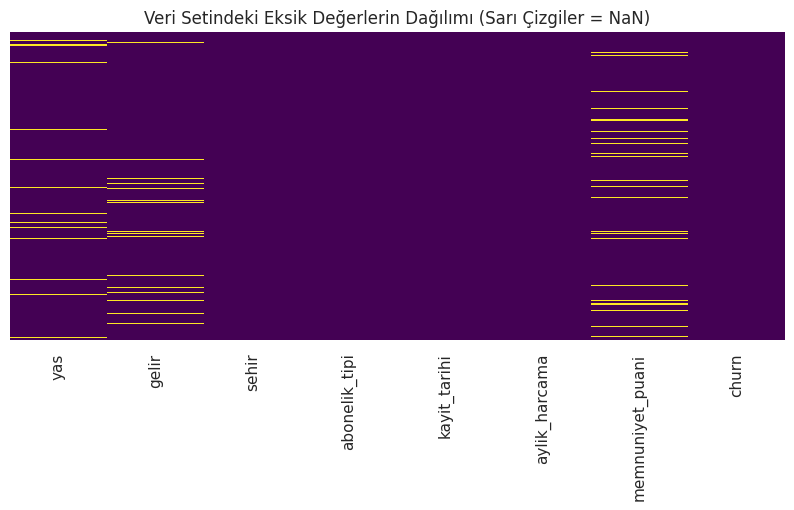

In [23]:
# Eksik Değer Isı Haritası (Heatmap)
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Veri Setindeki Eksik Değerlerin Dağılımı (Sarı Çizgiler = NaN)")
plt.show()

In [24]:
# Yinelenen (Duplicate) Kayıt Tespiti
tekrar_sayisi = df.duplicated().sum()
print(f"Veri setindeki birebir kopya (duplicate) satır sayısı: {tekrar_sayisi}")

Veri setindeki birebir kopya (duplicate) satır sayısı: 15


In [25]:

# Şehir sütunundaki ham dağılım
print("--- Temizlik Öncesi Şehir Dağılımı ---")
print(df["sehir"].value_counts())

--- Temizlik Öncesi Şehir Dağılımı ---
sehir
İstanbul    354
Ankara      198
istanbul    164
ANKARA      101
 İzmir      100
bursa        57
Bursa        41
Name: count, dtype: int64


In [26]:
# Şehir sütununu temizleme: Boşlukları kırpma, Türkçe karakter uyumu ve küçük harfe çevirme
df["sehir_temiz"] = df["sehir"].astype(str).str.strip().str.replace("İ", "i").str.lower()

In [27]:

print("\n--- Temizlik Sonrası Şehir Dağılımı ---")
print(df["sehir_temiz"].value_counts())




--- Temizlik Sonrası Şehir Dağılımı ---
sehir_temiz
istanbul    518
ankara      299
izmir       100
bursa        98
Name: count, dtype: int64


In [28]:
# Mantık dışı yaş değerlerinin (yaş < 0 veya yaş > 100) tespiti
anomali_yaslar = df[(df["yas"] < 0) | (df["yas"] > 100)]
print(f"\nTespit Edilen Mantık Dışı Yaş Kaydı Sayısı: {len(anomali_yaslar)}")
display(anomali_yaslar[["yas", "gelir", "sehir_temiz", "abonelik_tipi"]].head(10))


Tespit Edilen Mantık Dışı Yaş Kaydı Sayısı: 12


,yas,gelir,sehir_temiz,abonelik_tipi
82,-5.00,47012.14,ankara,Standart
153,150.00,18451.43,ankara,Standart
159,150.00,51690.22,ankara,Premium
169,150.00,46265.65,istanbul,VIP
192,150.00,20924.88,ankara,Standart
417,-5.00,26830.64,istanbul,Premium
434,-5.00,41078.97,ankara,Standart
569,150.00,38958.04,izmir,Premium
571,150.00,37606.74,istanbul,VIP
755,-5.00,29464.12,ankara,Standart


In [30]:
# Sayısal sütunların describe() özeti
print("--- Sayısal Sütunların Betimsel İstatistikleri ---")
display(df.describe())

--- Sayısal Sütunların Betimsel İstatistikleri ---


,yas,gelir,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
count,983.00,969.00,1015,1015.00,954.00,1015.00
mean,44.19,43318.77,2024-05-16 07:05:36.945812992,1450.32,3.25,0.21
min,-5.00,6037.45,2023-01-01 00:00:00,0.05,1.00,0.00
25%,31.00,29076.06,2023-09-09 12:00:00,399.42,2.00,0.00
50%,44.00,35760.05,2024-05-19 00:00:00,984.58,3.00,0.00
75%,56.00,42081.09,2025-01-19 12:00:00,1978.04,4.00,0.00
max,150.00,1069155.36,2025-09-26 00:00:00,9144.83,5.00,1.00
std,17.48,73222.87,NaN,1475.09,1.18,0.41


In [29]:
# Çarpıklık (Skewness) ve Basıklık (Kurtosis) Hesaplama
sayisal_kolonlar = ["yas", "gelir", "aylik_harcama", "memnuniyet_puani"]


In [31]:
dagilim_metrikleri = pd.DataFrame({
    "Çarpıklık (Skewness)": df[sayisal_kolonlar].skew(),
    "Basıklık (Kurtosis)": df[sayisal_kolonlar].kurt()
})

In [32]:
print("\n--- Çarpıklık ve Basıklık Değerleri ---")
display(dagilim_metrikleri)


--- Çarpıklık ve Basıklık Değerleri ---


,Çarpıklık (Skewness),Basıklık (Kurtosis)
yas,1.15,6.63
gelir,9.87,105.18
aylik_harcama,1.88,4.32
memnuniyet_puani,-0.32,-0.73


/tmp/ipykernel_2149/3685222451.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="memnuniyet_puani", data=df, ax=axes[1, 1], palette="crest")


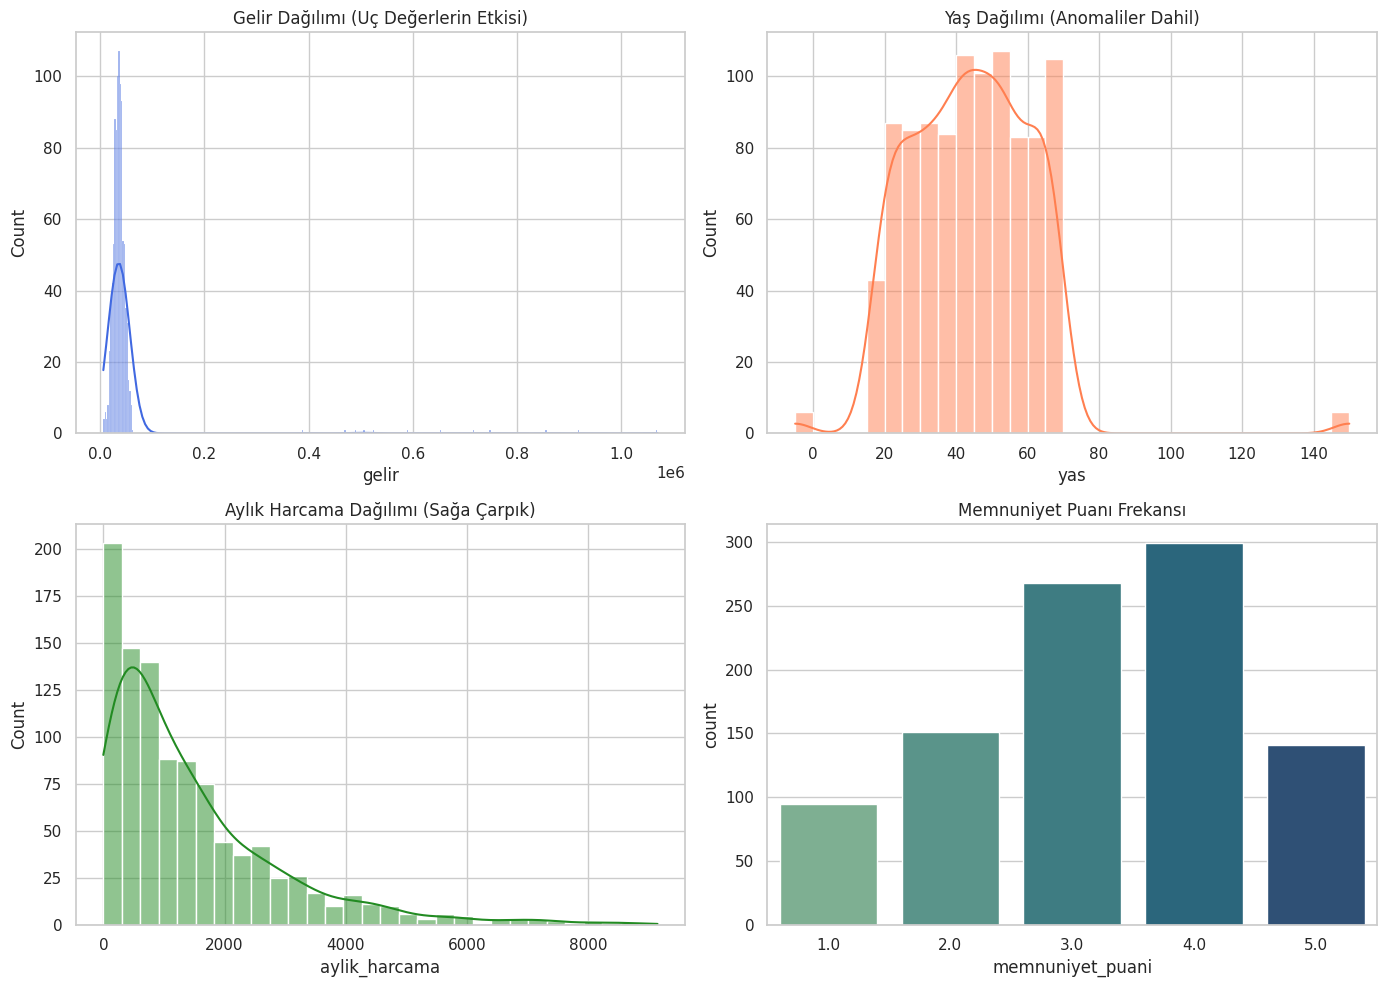

In [33]:
# Histogram ve Yoğunluk Eğrileri (KDE)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["gelir"].dropna(), kde=True, ax=axes[0, 0], color="royalblue")
axes[0, 0].set_title("Gelir Dağılımı (Uç Değerlerin Etkisi)")

sns.histplot(df["yas"].dropna(), kde=True, ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Yaş Dağılımı (Anomaliler Dahil)")

sns.histplot(df["aylik_harcama"], kde=True, ax=axes[1, 0], color="forestgreen")
axes[1, 0].set_title("Aylık Harcama Dağılımı (Sağa Çarpık)")

sns.countplot(x="memnuniyet_puani", data=df, ax=axes[1, 1], palette="crest")
axes[1, 1].set_title("Memnuniyet Puanı Frekansı")

plt.tight_layout()
plt.show()



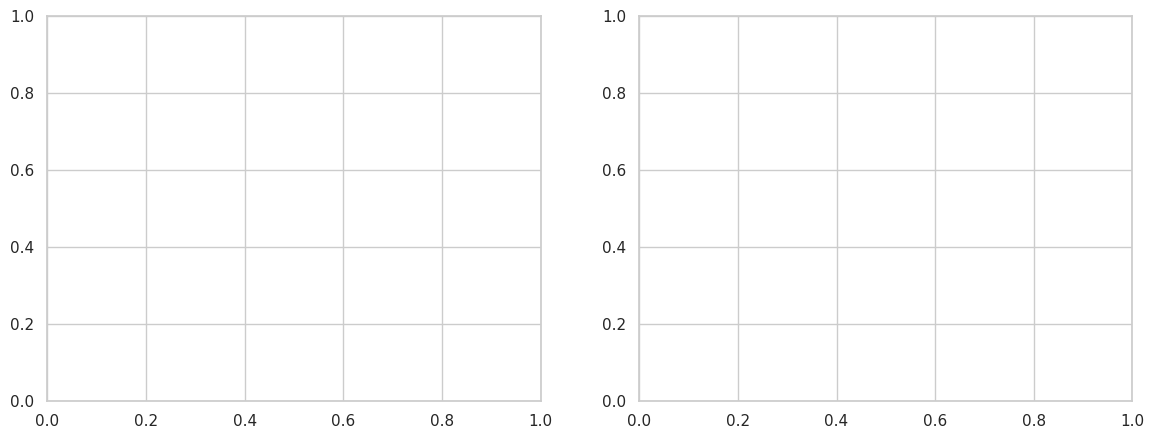

In [34]:
# Kutu Grafiği (Boxplot) ile Aykırı Değer Tespiti
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [36]:
sns.boxplot(x=df["gelir"], ax=axes[0], color="lightblue")
axes[0].set_title("Gelir Değişkeni Kutu Grafiği (Aykırı Değerler)")

sns.boxplot(x=df["aylik_harcama"], ax=axes[1], color="lightgreen")
axes[1].set_title("Aylık Harcama Kutu Grafiği")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

In [37]:
# Kategorik sütunların yüzdesel dağılımları
kategorik_kolonlar = ["sehir_temiz", "abonelik_tipi", "memnuniyet_puani", "churn"]

print("--- Kategorik Değişkenlerin Yüzdesel Dağılımı (%) ---")
for col in kategorik_kolonlar:
    print(f"\n{col.upper()} Sütunu Dağılımı:")
    yuzde = df[col].value_counts(normalize=True, dropna=False) * 100
    print(yuzde.round(2))



--- Kategorik Değişkenlerin Yüzdesel Dağılımı (%) ---

SEHIR_TEMIZ Sütunu Dağılımı:
sehir_temiz
istanbul   51.03
ankara     29.46
izmir       9.85
bursa       9.66
Name: proportion, dtype: float64

ABONELIK_TIPI Sütunu Dağılımı:
abonelik_tipi
Standart   49.36
Premium    37.24
VIP        13.40
Name: proportion, dtype: float64

MEMNUNIYET_PUANI Sütunu Dağılımı:
memnuniyet_puani
4.00   29.46
3.00   26.40
2.00   14.88
5.00   13.89
1.00    9.36
NaN     6.01
Name: proportion, dtype: float64

CHURN Sütunu Dağılımı:
churn
0   79.01
1   20.99
Name: proportion, dtype: float64


In [38]:
# Korelasyon Matrisi (Sadece sayısal sütunlar)
korelasyon = df[["yas", "gelir", "aylik_harcama", "memnuniyet_puani", "churn"]].corr()

In [39]:
print("\n--- Korelasyon Matrisi ---")
display(korelasyon)


--- Korelasyon Matrisi ---


,yas,gelir,aylik_harcama,memnuniyet_puani,churn
yas,1.00,0.03,-0.04,0.02,0.05
gelir,0.03,1.00,0.01,-0.03,-0.02
aylik_harcama,-0.04,0.01,1.00,-0.11,0.01
memnuniyet_puani,0.02,-0.03,-0.11,1.00,0.03
churn,0.05,-0.02,0.01,0.03,1.00


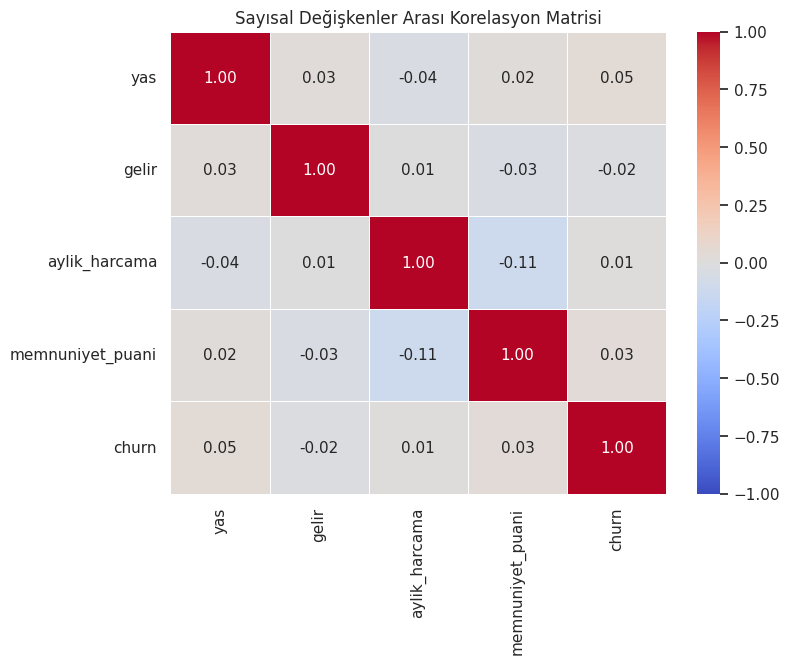

In [40]:
# Korelasyon Isı Haritası (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(korelasyon, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Sayısal Değişkenler Arası Korelasyon Matrisi")
plt.show()